# Exploratory Data Analysis

Performing Esports Analytics on League of Legends matches. The data contains the korean challanger players ranked matches.

**Origin of the data:** https://developer.riotgames.com

# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Importing the data

In [2]:
eda_df = pd.read_csv("eda_sample.csv")

# Initial data exploration

In [3]:
eda_df.head()

,matchId,minute,timestamp,currentGold_p1,currentGold_p2,currentGold_p3,currentGold_p4,currentGold_p5,currentGold_p6,currentGold_p7,...,cum_LEVEL_UP_diff,cum_TURRET_PLATE_DESTROYED_diff,cum_kill_magic_dmg_received_diff,cum_kill_true_dmg_received_diff,cum_WARD_PLACED_diff,cum_kill_phys_dmg_received_diff,cum_CHAMPION_KILL_diff,cum_ITEM_PURCHASED_diff,cum_BUILDING_KILL_diff,target_win_t100
0,KR_8031700522,0,0,500.0,500.0,500.0,500.0,100.0,500.0,500.0,...,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,2.0,0.0,0
1,KR_8031700522,1,60015,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,1.0,0.0,0.0,0.0,-4.0,0.0,0.0,2.0,0.0,0
2,KR_8031700522,2,120026,297.0,387.0,289.0,297.0,178.0,261.0,392.0,...,-2.0,0.0,0.0,0.0,-4.0,0.0,0.0,2.0,0.0,0
3,KR_8031700522,3,180027,569.0,784.0,610.0,659.0,378.0,645.0,794.0,...,1.0,0.0,536.0,170.0,-7.0,555.0,1.0,-3.0,0.0,0
4,KR_8031700522,4,240058,960.0,1778.0,26.0,1097.0,604.0,1009.0,165.0,...,0.0,0.0,536.0,170.0,-9.0,1441.0,2.0,1.0,0.0,0


In [4]:
eda_df.tail()

,matchId,minute,timestamp,currentGold_p1,currentGold_p2,currentGold_p3,currentGold_p4,currentGold_p5,currentGold_p6,currentGold_p7,...,cum_LEVEL_UP_diff,cum_TURRET_PLATE_DESTROYED_diff,cum_kill_magic_dmg_received_diff,cum_kill_true_dmg_received_diff,cum_WARD_PLACED_diff,cum_kill_phys_dmg_received_diff,cum_CHAMPION_KILL_diff,cum_ITEM_PURCHASED_diff,cum_BUILDING_KILL_diff,target_win_t100
66780,KR_8127863330,15,900398,361.0,3503.0,2215.0,1349.0,50.0,720.0,266.0,...,5.0,2.0,8851.0,670.0,-61.0,-1958.0,5.0,6.0,1.0,1
66781,KR_8127863330,16,960430,752.0,515.0,1097.0,484.0,281.0,1036.0,484.0,...,5.0,6.0,14001.0,1294.0,-75.0,-54.0,9.0,5.0,2.0,1
66782,KR_8127863330,17,1020462,273.0,2237.0,1684.0,2064.0,79.0,1858.0,841.0,...,6.0,7.0,17021.0,1431.0,-85.0,507.0,12.0,7.0,3.0,1
66783,KR_8127863330,18,1080464,1061.0,3037.0,562.0,289.0,396.0,203.0,442.0,...,5.0,7.0,17021.0,1431.0,-82.0,507.0,12.0,7.0,3.0,1
66784,KR_8127863330,19,1096323,1203.0,3214.0,615.0,476.0,443.0,318.0,505.0,...,5.0,7.0,17021.0,1431.0,-82.0,507.0,12.0,7.0,3.0,1


In [6]:
eda_df.shape # Shape of the dataset (rows, columns)

(66785, 672)

672 features, 66k rows

In [7]:
eda_df.info() # Summary of the dataset, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 66785 entries, 0 to 66784
Columns: 672 entries, matchId to target_win_t100
dtypes: float64(668), int64(3), str(1)
memory usage: 342.4 MB


In [8]:
eda_df.columns # List of column names in the dataset

Index(['matchId', 'minute', 'timestamp', 'currentGold_p1', 'currentGold_p2',
       'currentGold_p3', 'currentGold_p4', 'currentGold_p5', 'currentGold_p6',
       'currentGold_p7',
       ...
       'cum_LEVEL_UP_diff', 'cum_TURRET_PLATE_DESTROYED_diff',
       'cum_kill_magic_dmg_received_diff', 'cum_kill_true_dmg_received_diff',
       'cum_WARD_PLACED_diff', 'cum_kill_phys_dmg_received_diff',
       'cum_CHAMPION_KILL_diff', 'cum_ITEM_PURCHASED_diff',
       'cum_BUILDING_KILL_diff', 'target_win_t100'],
      dtype='str', length=672)

## Explanation of the columns:
* 'match_id': Unique identifier for each match.
* 'minute': The minute of the match when the event occurred.
* 'timestamp': The exact time when the event occurred.
* '*_p(1-10)': Player-specific statistics for each of the 10 players in the match, such as kills, deaths, assists, gold earned, etc.
* 'cum*_*': Cumulative statistics for each team up to that minute, such as cumulative kills, deaths, assists, gold earned, etc.
* '*diff': The difference in a specific statistic between the two teams at that minute, such as gold difference, kill difference, etc.
* 'target_win_t100': Target variable indicating whether team won the game


In [9]:
eda_df['matchId'].unique() # Unique values in the dataset

<StringArray>
['KR_8031700522', 'KR_8031786686', 'KR_8033124346', 'KR_8035806533',
 'KR_8036705617', 'KR_8037046690', 'KR_8037590215', 'KR_8038460687',
 'KR_8038872374', 'KR_8041032915',
 ...
 'KR_8126932260', 'KR_8126953234', 'KR_8127074850', 'KR_8127142412',
 'KR_8127206496', 'KR_8127336116', 'KR_8127425521', 'KR_8127487680',
 'KR_8127543182', 'KR_8127863330']
Length: 2475, dtype: str

2475 unique matches

In [10]:
eda_df.describe() # Statistical summary of numerical columns

,minute,timestamp,currentGold_p1,currentGold_p2,currentGold_p3,currentGold_p4,currentGold_p5,currentGold_p6,currentGold_p7,currentGold_p8,...,cum_LEVEL_UP_diff,cum_TURRET_PLATE_DESTROYED_diff,cum_kill_magic_dmg_received_diff,cum_kill_true_dmg_received_diff,cum_WARD_PLACED_diff,cum_kill_phys_dmg_received_diff,cum_CHAMPION_KILL_diff,cum_ITEM_PURCHASED_diff,cum_BUILDING_KILL_diff,target_win_t100
count,66785.000000,6.678500e+04,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,...,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000,66785.000000
mean,13.904679,8.334207e+05,580.666632,707.361249,581.209508,661.811425,417.018402,575.663757,697.452063,580.829228,...,0.111492,0.420004,183.514771,1.249053,0.065494,391.375638,0.386464,0.113064,0.120731,0.526825
std,9.177751,5.493781e+05,486.363829,588.937628,463.702648,570.908837,335.289849,476.740581,572.544276,467.510542,...,3.325448,7.234780,7304.327212,1609.854842,69.442084,8867.398411,7.477129,8.485727,2.633366,0.499284
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-14.000000,-35.000000,-56547.000000,-14685.000000,-1081.000000,-62179.000000,-45.000000,-45.000000,-18.000000,0.000000
25%,6.000000,3.601980e+05,232.000000,285.000000,251.000000,261.000000,170.000000,232.000000,283.000000,249.000000,...,-2.000000,-2.000000,-1885.000000,-331.000000,-7.000000,-2719.000000,-3.000000,-5.000000,0.000000,0.000000
50%,13.000000,7.803070e+05,490.000000,547.000000,500.000000,504.000000,346.000000,487.000000,542.000000,500.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,21.000000,1.260360e+06,799.000000,992.000000,803.000000,908.000000,581.000000,794.000000,977.000000,801.000000,...,2.000000,3.000000,2164.000000,333.000000,8.000000,3311.000000,4.000000,5.000000,0.000000,1.000000
max,57.000000,3.390182e+06,5583.000000,7703.000000,6997.000000,5781.000000,4674.000000,5061.000000,6890.000000,5410.000000,...,15.000000,35.000000,67045.000000,17883.000000,762.000000,63536.000000,35.000000,40.000000,14.000000,1.000000


In [12]:
eda_df[eda_df.duplicated()] # Check for duplicate rows in the dataset

,matchId,minute,timestamp,currentGold_p1,currentGold_p2,currentGold_p3,currentGold_p4,currentGold_p5,currentGold_p6,currentGold_p7,...,cum_LEVEL_UP_diff,cum_TURRET_PLATE_DESTROYED_diff,cum_kill_magic_dmg_received_diff,cum_kill_true_dmg_received_diff,cum_WARD_PLACED_diff,cum_kill_phys_dmg_received_diff,cum_CHAMPION_KILL_diff,cum_ITEM_PURCHASED_diff,cum_BUILDING_KILL_diff,target_win_t100


No duplicates.

In [14]:
eda_df.isnull().sum() # Check for missing values in each column

matchId                            0
minute                             0
timestamp                          0
currentGold_p1                     0
currentGold_p2                     0
                                  ..
cum_kill_phys_dmg_received_diff    0
cum_CHAMPION_KILL_diff             0
cum_ITEM_PURCHASED_diff            0
cum_BUILDING_KILL_diff             0
target_win_t100                    0
Length: 672, dtype: int64

## Visualizations

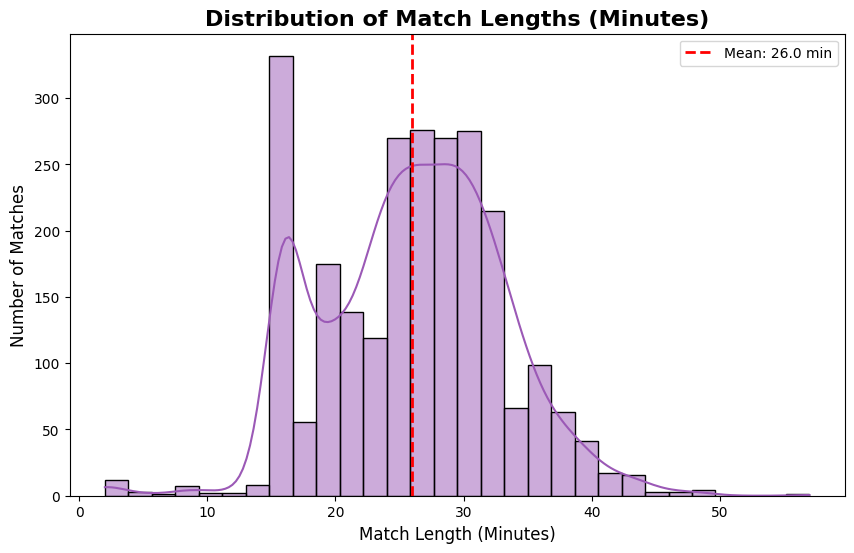

In [ ]:
# Get the maximum minute for each match
match_lengths = eda_df.groupby('matchId')['minute'].max()

plt.figure(figsize=(10, 6))
sns.histplot(match_lengths, bins=30, color='#9b59b6', kde=True)

plt.title('Distribution of Match Lengths (Minutes)', fontsize=16, fontweight='bold')
plt.xlabel('Match Length (Minutes)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.axvline(match_lengths.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {match_lengths.mean():.1f} min')
plt.legend()
plt.show()

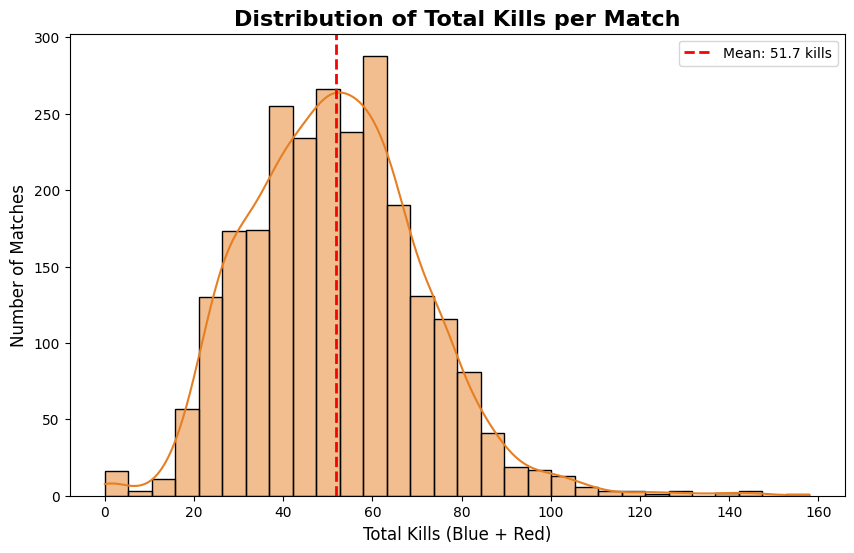

In [27]:
# Get the total kills at the very last minute of each match
# We add Blue (t100) and Red (t200) cumulative kills together
last_minute_df = eda_df.loc[eda_df.groupby('matchId')['minute'].idxmax()]

total_kills = last_minute_df['cum_CHAMPION_KILL_t100'] + last_minute_df['cum_CHAMPION_KILL_t200']
    
plt.figure(figsize=(10, 6))
sns.histplot(total_kills, bins=30, color='#e67e22', kde=True)
    
plt.title('Distribution of Total Kills per Match', fontsize=16, fontweight='bold')
plt.xlabel('Total Kills (Blue + Red)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.axvline(total_kills.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {total_kills.mean():.1f} kills')
plt.legend()
plt.show()

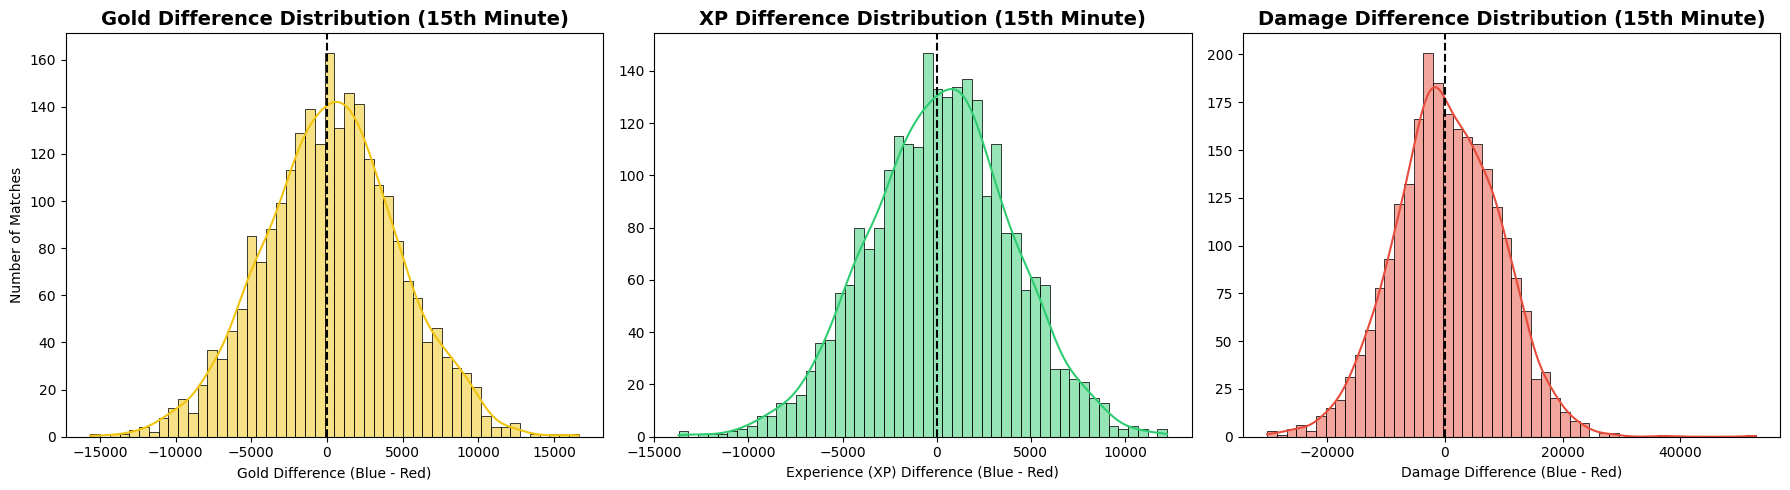

In [28]:
# Filter the dataset for the 15th minute
min15_df = eda_df[eda_df['minute'] == 15].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gold difference distribution
sns.histplot(min15_df['totalGold_diff'], bins=50, ax=axes[0], color='#f1c40f', kde=True)
axes[0].set_title('Gold Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gold Difference (Blue - Red)')
axes[0].set_ylabel('Number of Matches')
axes[0].axvline(0, color='black', linestyle='--')

# 2. XP difference distribution
sns.histplot(min15_df['xp_diff'], bins=50, ax=axes[1], color='#2ecc71', kde=True)
axes[1].set_title('XP Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Experience (XP) Difference (Blue - Red)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linestyle='--')

# 3. Damage difference distribution
sns.histplot(min15_df['dmg_totalDamageDoneToChampions_diff'], bins=50, ax=axes[2], color='#e74c3c', kde=True)
axes[2].set_title('Damage Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Damage Difference (Blue - Red)')
axes[2].set_ylabel('')
axes[2].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

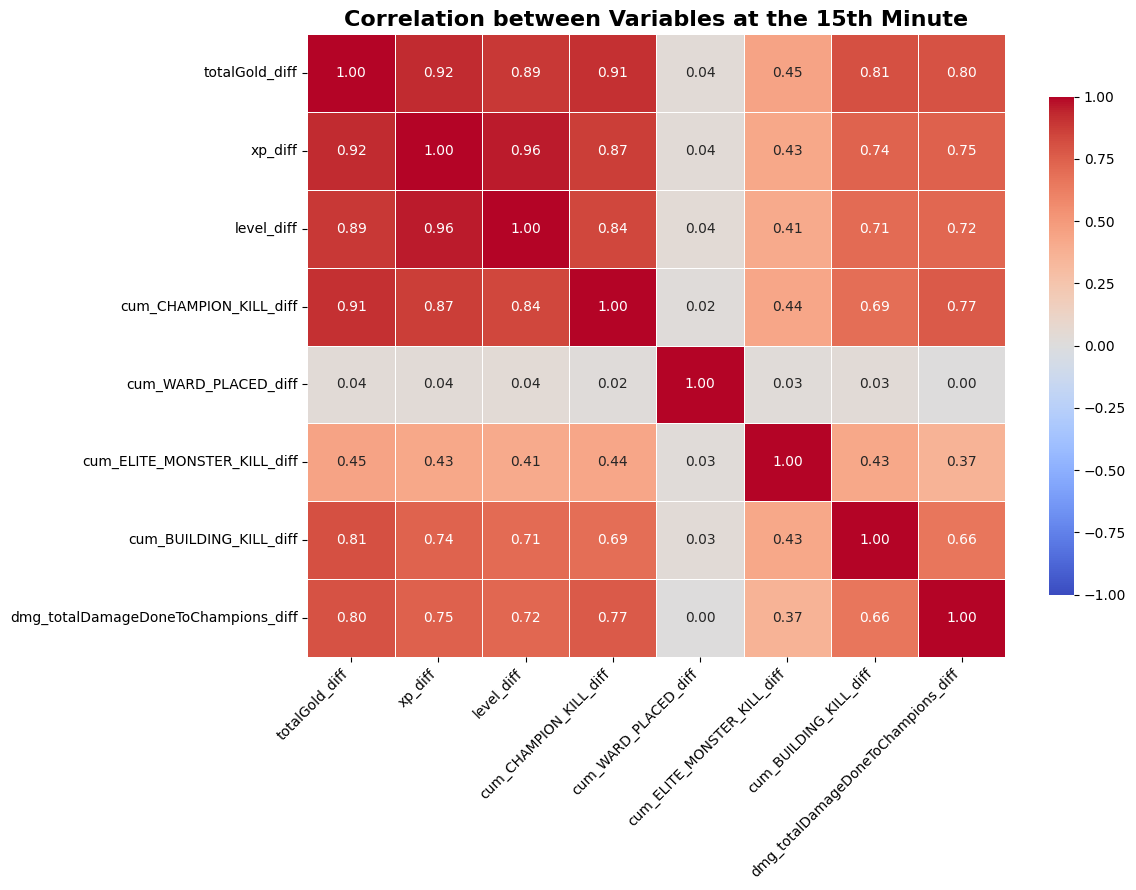

In [29]:
# Most likely to be correlated with the final outcome (win/loss) at the 15th minute:
cols_for_corr = [
    'totalGold_diff', 
    'xp_diff', 
    'level_diff', 
    'cum_CHAMPION_KILL_diff',
    'cum_WARD_PLACED_diff',
    'cum_ELITE_MONSTER_KILL_diff',
    'cum_BUILDING_KILL_diff',
    'dmg_totalDamageDoneToChampions_diff'
]

# Validate that the columns exist in the DataFrame before calculating the correlation matrix
valid_cols = [c for c in cols_for_corr if c in min15_df.columns]

# Calculate the correlation matrix for the valid columns
corr_matrix = min15_df[valid_cols].corr()

# Vizualization of the correlation matrix using a heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, 
            annot=True,          
            cmap='coolwarm',     
            fmt=".2f",           
            vmin=-1, vmax=1,    
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation between Variables at the 15th Minute', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for kill coordinates

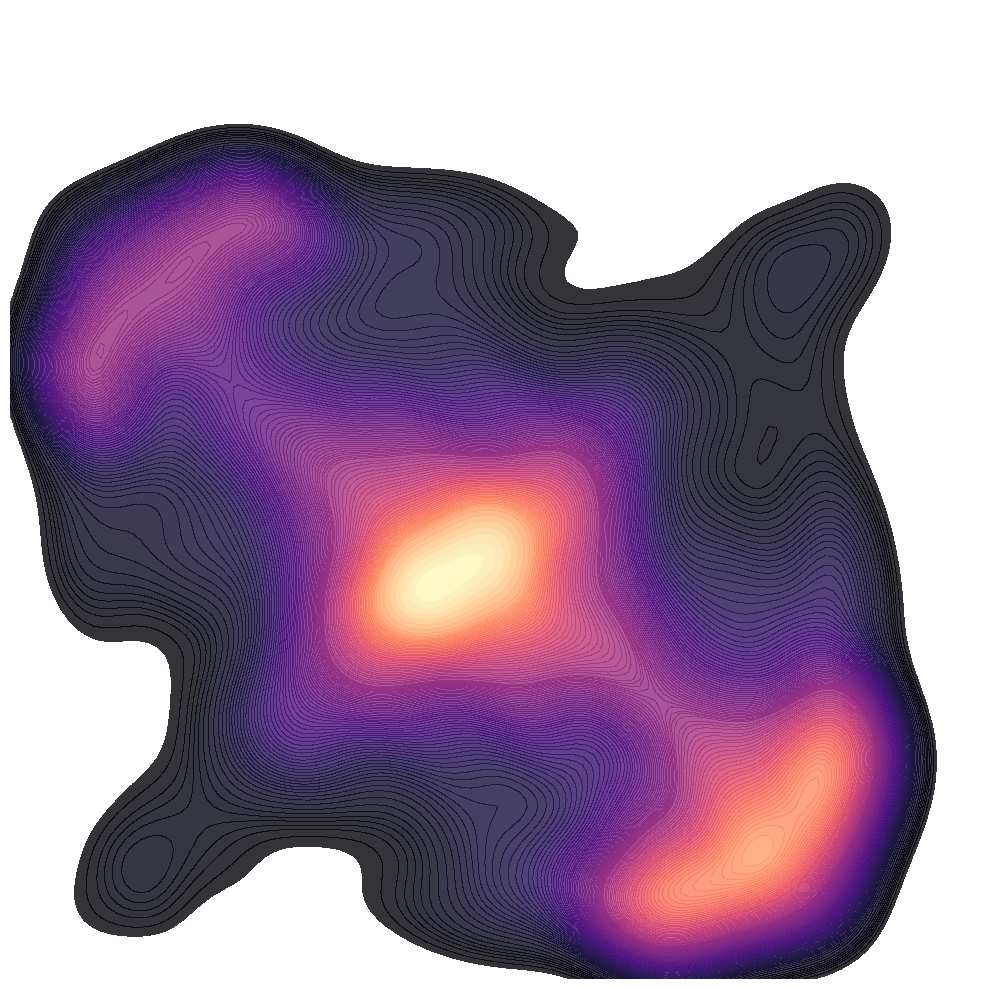

In [46]:
# Reading the raw events file to create a spatial heatmap of kills
RAW_FILE = "Data/Timelines/Raw_Batches/events_batch_1.csv"

if os.path.exists(RAW_FILE):
    events_raw = pd.read_csv(RAW_FILE, low_memory=False)
    
    x_col = 'positionX'
    y_col = 'positionY'
    
    if x_col in events_raw.columns and y_col in events_raw.columns:
        # Filter the events for CHAMPION_KILL and valid coordinates
        kills = events_raw[(events_raw['type'] == 'CHAMPION_KILL') & (events_raw[x_col].notna())]
        
        # Setting up the plot (Square aspect ratio for accurate map representation)
        plt.figure(figsize=(10, 10))
        plt.gca().set_facecolor('#1a1a1a') 
        
        # Seaborn 2D Heatmap for kill locations
        sns.kdeplot(
            x=kills[x_col], 
            y=kills[y_col], 
            cmap="magma",       
            fill=True, 
            levels=100,
            alpha=0.8
        )
        
        plt.title("Kill (CHAMPION_KILL) Heatmap\n(Korean Challenger - Batch 1)", 
                  color='white', fontsize=18, fontweight='bold', pad=20)
        
        # Setting the limits to match the Summoner's Rift dimensions
        plt.xlim(0, 16000)
        plt.ylim(0, 16000)
        
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Error: Not found ({x_col}, {y_col}) in the file!")
else:
    print(f"Error: Raw file not found: {RAW_FILE}")